In [4]:
import sys
!{sys.executable} -m pip install numpy pandas matplotlib
# Instala las librerías en el kernel que estás usando AHORA



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
#Librerias necesarias para el desarrollo de este ejercicio 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
# Definir los datos
proyectos = {
    "ID": ["P1", "P2", "P3", "P4", "P5", "P6", "P7", "P8", "P9", "P10"],
    "Costo": [10, 15, 20, 25, 30, 35, 40, 45, 50, 55],
    "Retorno": [5, 8, 12, 15, 18, 22, 25, 28, 30, 35],
}

df_proyectos = pd.DataFrame(proyectos)
presupuesto_maximo = 100

print("Proyectos disponibles:")
print(df_proyectos)
print(f"\nPresupuesto máximo: ${presupuesto_maximo}")

Proyectos disponibles:
    ID  Costo  Retorno
0   P1     10        5
1   P2     15        8
2   P3     20       12
3   P4     25       15
4   P5     30       18
5   P6     35       22
6   P7     40       25
7   P8     45       28
8   P9     50       30
9  P10     55       35

Presupuesto máximo: $100


In [ ]:
def crear_cromosoma(tamano):
    """Crea un cromosoma binario aleatorio."""
    return np.random.randint(0, 2, tamano)


def calcular_fitness(cromosoma, df_proyectos, budget):
    """
    Calcula la aptitud del cromosoma.

    Si el costo total supera el presupuesto, se aplica una penalización.
    """
    seleccionados = df_proyectos.iloc[np.where(cromosoma == 1)[0]]

    if len(seleccionados) == 0:
        return 0, 0, 0

    costo_total = seleccionados["Costo"].sum()
    retorno_total = seleccionados["Retorno"].sum()

    if costo_total > budget:
        penalizacion = (costo_total - budget) * 10
        fitness = retorno_total - penalizacion
        return retorno_total, costo_total, fitness

    return retorno_total, costo_total, retorno_total


def crossover_punto_doble(padre1, padre2):
    """Realiza un cruzamiento de dos puntos entre dos padres."""
    tamano = len(padre1)
    punto1 = np.random.randint(1, tamano - 1)
    punto2 = np.random.randint(punto1 + 1, tamano)

    hijo1 = np.concatenate(
        [padre1[:punto1], padre2[punto1:punto2], padre1[punto2:]]
    )
    hijo2 = np.concatenate(
        [padre2[:punto1], padre1[punto1:punto2], padre2[punto2:]]
    )

    return hijo1, hijo2

In [ ]:
def algoritmo_genetico(num_generaciones=50, tamano_poblacion=20, prob_mutacion=0.1):
    num_proyectos = len(df_proyectos)
    mejor_fitness = -np.inf
    mejor_cromosoma = None

    for gen in range(num_generaciones):
        # Inicializar población
        poblacion = [
            crear_cromosoma(num_proyectos)
            for _ in range(tamano_poblacion)
        ]

        # Evaluar fitness
        poblacion_fitness = [
            calcular_fitness(cromosoma, df_proyectos, presupuesto_maximo)[2]
            for cromosoma in poblacion
        ]

        # Encontrar el mejor de la generación
        mejor_idx = np.argmax(poblacion_fitness)
        if poblacion_fitness[mejor_idx] > mejor_fitness:
            mejor_fitness = poblacion_fitness[mejor_idx]
            mejor_cromosoma = poblacion[mejor_idx].copy()

        # Selección por torneo y reproducción
        nueva_poblacion = []
        for _ in range(tamano_poblacion):
            padre1_idx, padre2_idx = np.random.choice(
                tamano_poblacion,
                2,
                replace=False
            )

            # Cruzamiento
            if np.random.random() < 0.8:
                hijo1, hijo2 = crossover_punto_doble(
                    poblacion[padre1_idx],
                    poblacion[padre2_idx]
                )
                hijos = [hijo1, hijo2]
            else:
                hijos = [
                    poblacion[padre1_idx].copy(),
                    poblacion[padre2_idx].copy()
                ]

            # Mutación
            for hijo in hijos:
                for indice in range(len(hijo)):
                    if np.random.random() < prob_mutacion:
                        hijo[indice] = 1 - hijo[indice]

            nueva_poblacion.extend(hijos)

        # Mantener el tamaño de la población
        poblacion = nueva_poblacion[:tamano_poblacion]

    return mejor_cromosoma, mejor_fitness


# Ejecutar y mostrar resultados
print("\n=== Ejecutando Algoritmo Genético ===")
mejor_solucion, mejor_retorno = algoritmo_genetico()

# Mostrar resultados
print(f"\nMejor cromosoma encontrado: {mejor_solucion}")
print(f"Mejor retorno: ${mejor_retorno}")

# Identificar proyectos seleccionados
proyectos_seleccionados = df_proyectos.iloc[np.where(mejor_solucion == 1)[0]]
print("\nProyectos seleccionados:")
print(proyectos_seleccionados)

# Calcular métricas finales
costo_total = proyectos_seleccionados["Costo"].sum()
retorno_total = proyectos_seleccionados["Retorno"].sum()
print(f"\nCosto total: ${costo_total}")
print(f"Retorno total: ${retorno_total}")

if costo_total <= presupuesto_maximo:
    print("Solución VIABLE (dentro del presupuesto)")
else:
    exceso = costo_total - presupuesto_maximo
    print(f"Solución INVIABLE (excede presupuesto por ${exceso})")


=== Ejecutando Algoritmo Genético ===

Mejor cromosoma encontrado: [0 0 0 1 0 1 1 0 0 0]
Mejor retorno: $62

Proyectos seleccionados:
   ID  Costo  Retorno
3  P4     25       15
5  P6     35       22
6  P7     40       25

Costo total: $100
Retorno total: $62
✅ Solución VIABLE (dentro del presupuesto)


<Figure size 1000x600 with 0 Axes>

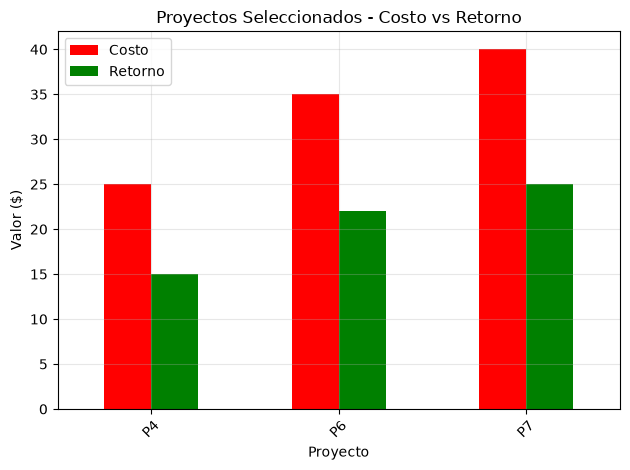

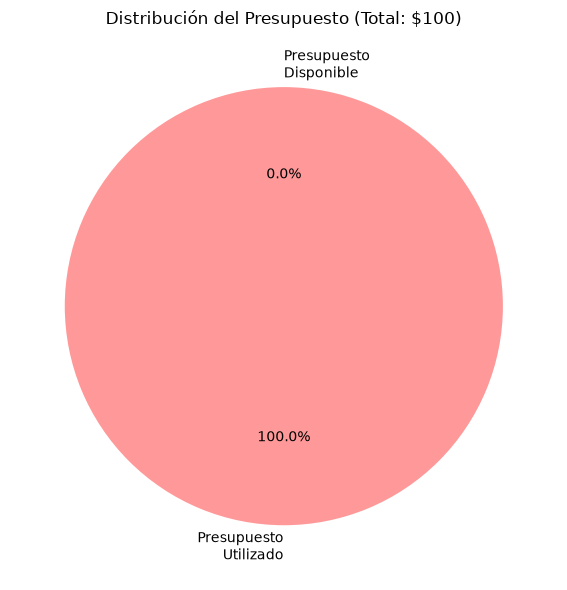

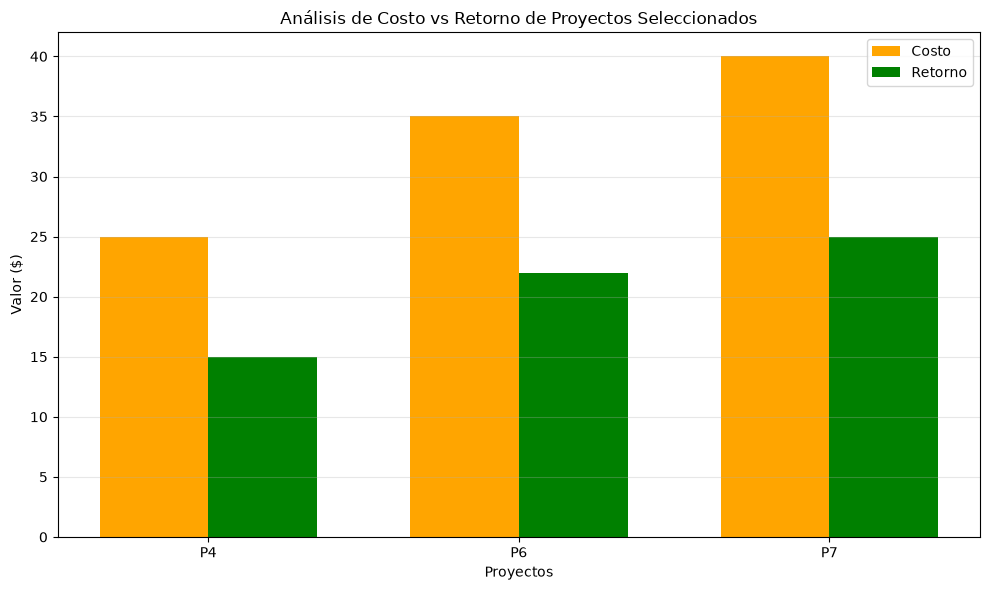

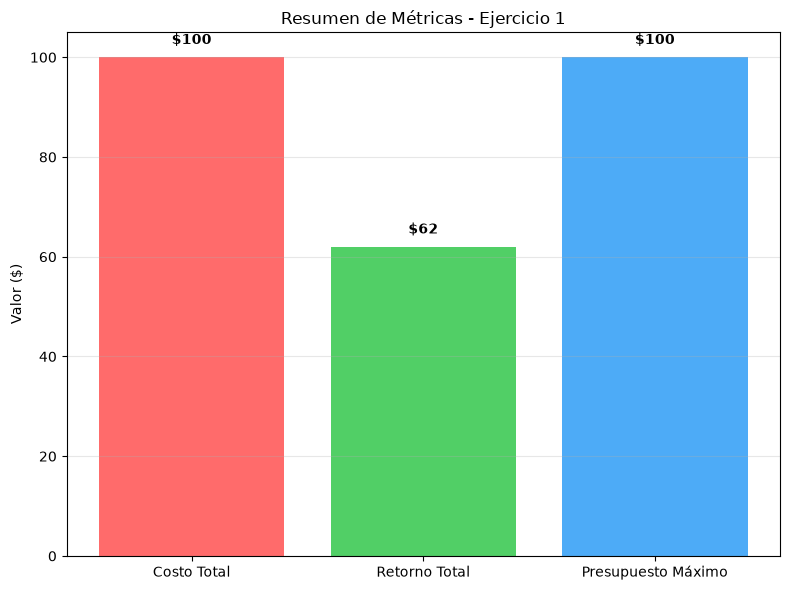

In [10]:
# Gráfica 1: Proyectos seleccionados y sus costos
plt.figure(figsize=(10, 6))
proyectos_seleccionados.plot(x='ID', y=['Costo', 'Retorno'], kind='bar', color=['red', 'green'])
plt.title('Proyectos Seleccionados - Costo vs Retorno')
plt.xlabel('Proyecto')
plt.ylabel('Valor ($)')
plt.xticks(rotation=45)
plt.legend(['Costo', 'Retorno'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Gráfica 2: Resumen de inversión
labels = ['Presupuesto\nUtilizado', 'Presupuesto\nDisponible']
valores = [costo_total, presupuesto_maximo - costo_total]
colores = ['#ff9999', '#66b3ff']
plt.figure(figsize=(8, 6))
plt.pie(valores, labels=labels, autopct='%1.1f%%', colors=colores, startangle=90)
plt.title(f'Distribución del Presupuesto (Total: ${presupuesto_maximo})')
plt.tight_layout()
plt.show()

# Gráfica 3: Comparación de retorno vs costo
plt.figure(figsize=(10, 6))
x_pos = np.arange(len(proyectos_seleccionados))
width = 0.35
plt.bar(x_pos - width/2, proyectos_seleccionados['Costo'], width, label='Costo', color='orange')
plt.bar(x_pos + width/2, proyectos_seleccionados['Retorno'], width, label='Retorno', color='green')
plt.xlabel('Proyectos')
plt.ylabel('Valor ($)')
plt.title('Análisis de Costo vs Retorno de Proyectos Seleccionados')
plt.xticks(x_pos, proyectos_seleccionados['ID'])
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Gráfica 4: Resumen de métricas
metricas = ['Costo Total', 'Retorno Total', 'Presupuesto Máximo']
valores_metricas = [costo_total, retorno_total, presupuesto_maximo]
colores_metricas = ['#ff6b6b', '#51cf66', '#4dabf7']
plt.figure(figsize=(8, 6))
plt.bar(metricas, valores_metricas, color=colores_metricas)
plt.ylabel('Valor ($)')
plt.title('Resumen de Métricas - Ejercicio 1')
plt.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(valores_metricas):
    plt.text(i, v + 2, f'${v}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()